In [1]:
# Osteoporosis Fracture Risk Modeling Project
# Ana Bjelica | 2026


In [2]:
# The structure of this project is inspired by the Data Life Cycle, which includes the following
# steps:
# Step 0: Configure Notebook & Choose Programming Language
# Step 1: Project Definition & Overview
# Step 2: Data Acquisition & Audience Acknowledgement
# Step 3: Data Shaping
# Step 4: Exploratory Data Analysis (EDA) & Visualization
# Step 5: Model Building 
# Step 6: Model Validation, Visualization, & Interpretation 
# Step 7: Data Story Development
# Step 8: Discussion & Reflection on the DSA Life Cycle

In [3]:
# Step 0: The language I chose for this project is Python.

In [4]:
# Step 1: This data project attempts to address the following question: which Missouri state counties 
# have the highest unmet osteoporosis-related fracture risk? 
# Fracture risk caused by low bone density affects over 40 million Americans.¹ Studies have estimated 
# that around 50% of women and 20% of men will break a bone due to osteoporosis in their lifetime.² 
# Fracture risk is often exacerbated in vulnerable populations with limited healthcare access 
# and a high socioeconomic burden. Factors associated with increased fracture risk include advanced 
# age, sex (female), low income, low socioeconomic status, and regional medical vulnerability.³,⁴ 
# The goal of this project is to use Missouri county-level data to identify counties associated 
# with these risk factors, and to perhaps suggest areas for future public health interventions. 

In [5]:
# Step 2: The project comments and visuals are designed to be understandable for those who may not 
# have an extensive background in osteoporosis or clinical data, while remaining engaging to audience
# members with data science familiarity.  

# The data used for this project has already been acquired and downloaded. It is a county-level Missouri demographic
# dataset with information that includes population structure, socioeconomic factors, healthcare availability, and more.
# Individual factors from this dataset will be chosen to represent and quantify fracture risk in the state of Missouri. 

In [6]:
# Step 3: In this step, the data is staged.
# The first task is to import necessary packages. 
import pandas as pd # importing Pandas
# Next - loading the Missouri county dataset.
df_MC = pd.read_csv("/kaggle/input/datasets/anabjelica/mo-county-dataset/MO_County_Data_CSV_DSA7010_Project_Data (1).csv")
# Checking to make sure the data loaded correctly:
df_MC.head()

,cnty_fips,cnty_name,povpct,pop_2014,pop_densit,age_lt18,pct_age_lt,age_18_65,pct_age_18,age_gt_65,...,COVVac1Dos,COVFullVac,PctCOV1Dos,PctCOVFull,Cen2000PR,Cen2010PR,AllC_AAIRt,AllC_AvAnC,AllC_Statu,AllC_Rec5Y
0,29001,Adair,26.9,25602,44.864523,4759,18.6,17400,68.0,3443,...,9899,8783,0.39,0.35,0.79,0.81,456.3,116,stable,0.0
1,29003,Andrew,10.7,17379,39.784793,4020,23.1,10393,59.8,2967,...,5414,4879,0.31,0.28,0.81,0.79,427.3,98,stable,-0.1
2,29005,Atchison,12.2,5382,9.795111,1078,20.0,3046,56.6,1258,...,2364,2131,0.45,0.40,0.77,0.74,393.4,32,stable,-0.9
3,29007,Audrain,17.2,25887,37.117682,6068,23.4,15554,60.1,4265,...,8465,7161,0.33,0.28,0.79,0.80,464.9,148,falling,-1.0
4,29009,Barry,20.2,35662,45.068915,8321,23.3,20248,56.8,7093,...,14197,11608,0.40,0.33,0.69,0.60,386.1,196,stable,-0.7


In [7]:
# Step 3 (cont'd): The risk factors used to estimate comparative unmet osteoporosis-related 
# fracture risk are organized, to begin with, into three separate domains:
# A. Biological risk
# B. Socioeconomic vulnerability
# C. Healthcare access 
# Each domain is calculated for each county based on its individual variables.
# The variables are first stored in lists and then used to select columns from the original 
# data frame, and then combined into a new data frame. 
# For biological risk, those variables are: 
#            - The percentage of the county population aged 65-74
#            - The percentage of the county population aged 75+
#            - The percentage of the county population that is female
biological_risk = ["P_A65_74", "P_A75up", "female_pct"]
# For socioeconomic vulnerability, the selected variables are: 
#            - The percentage of the county population that is unemployed
#            - The percentage of the county population subject to food insecurity
#            - The percentage of the county population that is below the poverty level
#            - The percentage of the county population that has less than a high school education
SE_vulnerability = ["pct_unempl", "food_insec", "P_BPovLev", "P_EDUC_LTH"]
# For healthcare access, the selected variables are: 
#            - The average number of minutes needed to travel to the nearest urgent care center
#            - The average number of minutes needed to travel to the nearest nursing home
#            - The average number of minutes needed to travel to the nearest hospital
#            - The average number of physicians per capita 
#            - The percentage of the county population that is medically uninsured
HC_access = ["AveMinHosp", "AveMinUrgC", "AveMinNurs", "pcp_per_cap", "PctUninsur"]
# A separate list for the county names:
County_names = ["cnty_name"]
# The four lists are used to select columns for a new data frame:
df_new = df_MC[County_names + biological_risk + SE_vulnerability + HC_access]
# Checking to make sure the data loaded correctly.
df_new.head()

,cnty_name,P_A65_74,P_A75up,female_pct,pct_unempl,food_insec,P_BPovLev,P_EDUC_LTH,AveMinHosp,AveMinUrgC,AveMinNurs,pcp_per_cap,PctUninsur
0,Adair,9.6,7.8,52.0,5.4,17,28.0,9.4,14.1456,67.5000,12.68980,0.001250,8.5
1,Andrew,13.4,10.2,50.6,4.8,11,8.6,8.1,17.6525,18.5812,12.86290,0.000115,7.1
2,Atchison,17.3,13.7,50.4,5.2,13,9.6,9.4,10.3444,59.9217,9.93395,0.000372,8.5
3,Audrain,12.4,9.8,54.6,5.8,15,13.5,14.5,15.9984,40.9525,9.78588,0.000695,10.0
4,Barry,14.8,10.9,50.3,5.8,14,17.7,17.8,11.3349,24.7225,13.32420,0.000505,15.5


In [8]:
# Step 3 (cont'd): From the printed data above, we can see that the percentages are stored as
# whole-number percentage values (not decimals or fractions).
# The next task is to clean the data, which involves removing any invalid 
# or missing data from the new data frame. 
df_new = df_new.dropna() # Removing any NA values
# In order to perform calculations or numerical analysis with the data, it is important that all 
# the values are numeric. The following command checks the data type of the values. 
df_new.dtypes

cnty_name       object
P_A65_74       float64
P_A75up        float64
female_pct     float64
pct_unempl     float64
food_insec       int64
P_BPovLev      float64
P_EDUC_LTH     float64
AveMinHosp     float64
AveMinUrgC     float64
AveMinNurs     float64
pcp_per_cap    float64
PctUninsur     float64
dtype: object

In [9]:
# It appears that all the data (besides county names) are stored as either integers or floats, 
# which means we can move on to Step 4. 

In [10]:
# To begin with, here is a table that contains relevant summary statistics for each county data: 
df_new.describe()

,P_A65_74,P_A75up,female_pct,pct_unempl,food_insec,P_BPovLev,P_EDUC_LTH,AveMinHosp,AveMinUrgC,AveMinNurs,pcp_per_cap,PctUninsur
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,13.733043,10.742609,50.163478,6.493043,15.469565,14.786087,13.869565,17.764431,37.692031,11.659754,0.000434,11.954783
std,2.570368,2.235403,1.962291,1.159909,2.099798,4.422012,4.507288,6.410804,19.258977,2.199412,0.000284,4.203262
min,8.500000,5.800000,37.100000,4.100000,11.000000,5.000000,4.700000,7.113420,7.526580,7.500060,0.000000,4.900000
25%,12.100000,9.250000,49.650000,5.700000,14.000000,11.800000,10.950000,13.168550,20.309000,10.098550,0.000221,8.800000
50%,13.400000,10.700000,50.400000,6.400000,15.000000,14.300000,13.000000,16.041000,34.853000,11.526200,0.000388,11.500000
75%,14.950000,12.200000,51.050000,7.300000,16.500000,17.500000,16.250000,22.136350,56.011800,12.976350,0.000603,14.450000
max,23.900000,16.400000,55.100000,10.000000,26.000000,28.000000,25.500000,40.392300,67.500000,18.689500,0.001250,35.400000


In [11]:
# Step 4: Now it is time to perform exploratory data analysis (EDA) and vet the newly organized
# data. First, it is necessary to check that there are no missing outliers, negative numbers (which
# could be either errors or placeholders), and the data are properly directionally aligned. 
# Checking for missing values:
df_new.isnull().sum()

cnty_name      0
P_A65_74       0
P_A75up        0
female_pct     0
pct_unempl     0
food_insec     0
P_BPovLev      0
P_EDUC_LTH     0
AveMinHosp     0
AveMinUrgC     0
AveMinNurs     0
pcp_per_cap    0
PctUninsur     0
dtype: int64

In [12]:
# According to the output, there are no missing values in any of the columns. 
# Checking for any negative values in the data frame: (using NumPy) 
(df_new.select_dtypes(include='float') < 0).any().any() # Checking the float values

np.False_

In [13]:
(df_new.select_dtypes(include='int') < 0).any().any() # Checking the integer values

np.False_

<Axes: >

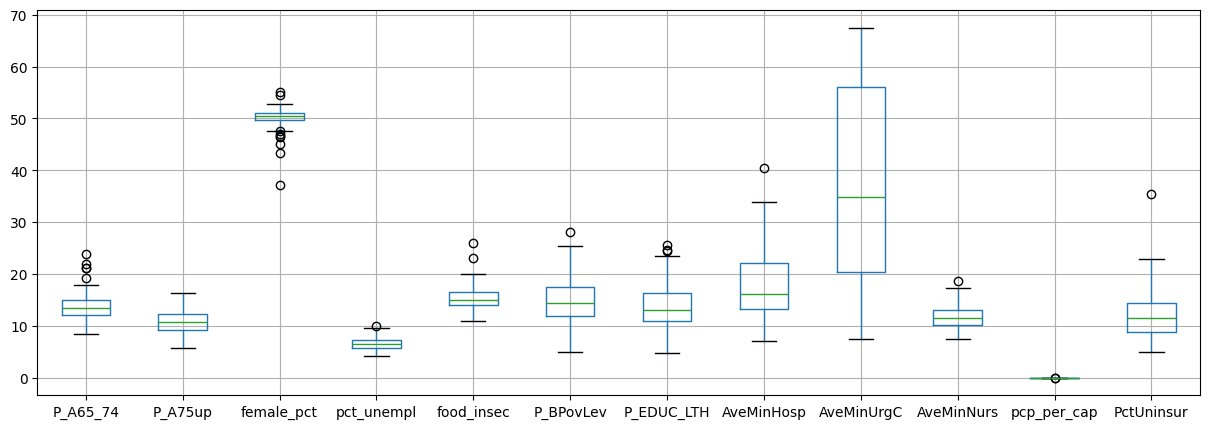

In [14]:
# According to the output, there are no negative numbers in any of the columns. 
# Visualizations, especially box plots, can be useful to check for any extreme outliers 
# in the data. This is an important step before building the model,
# because extreme outliers can potentially skew summary statistics or results. 
# Creating a box plot:
df_new.boxplot(figsize=(15,5))

In [15]:
# There appear to be two major outliers - the maximum value for the average minutes to the 
# nearest hospital (AveMinHosp), and the maximum value for the percentage of the population that is 
# uninsured (PctUninsur). To see which counties are responsible for these outliers,
# we can check the maximum values of each corresponding column, and then double-check if the outliers 
# seem reasonable based on internal data and external sources.  
# Checking which county has the maximum average minutes to the nearest hospital:
df_new[df_new["AveMinHosp"] == df_new["AveMinHosp"].max()] 


,cnty_name,P_A65_74,P_A75up,female_pct,pct_unempl,food_insec,P_BPovLev,P_EDUC_LTH,AveMinHosp,AveMinUrgC,AveMinNurs,pcp_per_cap,PctUninsur
33,Douglas,16.9,12.7,50.5,7.3,17,17.6,18.6,40.3923,33.6777,14.9517,0.0,14.9


In [16]:
# The average number of minutes to a hospital in Douglas county is 40, which is larger than the average
# for Missouri (which is around 14 minutes, according to the summary statistics table). This is 
# because Douglas county is largely rural and, as confirmed by online data sources, known 
# to have no hospitals.⁵

In [17]:
# Checking which county has the maximum percentage of uninsured residents:
df_new[df_new["PctUninsur"] == df_new["PctUninsur"].max()]

,cnty_name,P_A65_74,P_A75up,female_pct,pct_unempl,food_insec,P_BPovLev,P_EDUC_LTH,AveMinHosp,AveMinUrgC,AveMinNurs,pcp_per_cap,PctUninsur
98,Scotland,13.2,12.2,50.6,4.8,14,13.3,22.9,11.9328,67.5,12.7881,0.001028,35.4


In [18]:
# According to the output, Scotland county has a 35.4% uninsured population, compared to the state average of about 12%. 
# External data sources support the validity of this statistic, claiming that the percentage of 
# uninsured residents of Scotland county skyrocketed from around 15% in 2023 to over 30% in 2024.⁶
# Checking external data sources can confirm that the major outliers are genuine and not data entry errors.

In [19]:
# Step 5: The data is now cleaned, organized and vetted, so now we can move on to construction of the 
# statistical scoring model. To begin with, z-score standardization is necessary to place all the 
# values on the same scale so they can be fairly compared. A z-score assigns a value 
# based on how far each observation is from the average, or mean, of all county values.

In [20]:
# Importing statistical z-score package: 
from scipy.stats import zscore
# Creating a new data frame with only numerical values:
df_Z = df_new.drop(columns = ["cnty_name"])
# Applying z-score standardization to all values:
df_Z = df_Z.apply(zscore)
# Adding the county names to the new data frame:
df_Z["cnty_name"] = df_new["cnty_name"].values
# Checking to make sure the scoring translated correctly:
df_Z.head()

,P_A65_74,P_A75up,female_pct,pct_unempl,food_insec,P_BPovLev,P_EDUC_LTH,AveMinHosp,AveMinUrgC,AveMinNurs,pcp_per_cap,PctUninsur,cnty_name
0,-1.614995,-1.322127,0.940003,-0.946477,0.732038,3.001290,-0.995970,-0.566960,1.554518,0.470377,2.889125,-0.825526,Adair
1,-0.130137,-0.243796,0.223429,-1.466022,-2.137884,-1.405053,-1.285655,-0.017536,-0.996650,0.549424,-1.130575,-1.160058,Andrew
2,1.393795,1.328769,0.121061,-1.119658,-1.181243,-1.177922,-0.995970,-1.162491,1.159301,-0.788100,-0.221916,-0.825526,Atchison
3,-0.520889,-0.423518,2.270784,-0.600113,-0.224603,-0.292110,0.140482,-0.276683,0.170037,-0.855717,0.924751,-0.467099,Audrain
4,0.416915,0.070717,0.069877,-0.600113,-0.702923,0.661840,0.875834,-1.007310,-0.676375,0.760080,0.249650,0.847136,Barry


In [21]:
# Step 5 (cont'd): The next task is to directionally align the z-scores.
# For the purposes of this model, a higher score indicates greater fracture risk, while a lower score
# indicates lower fracture risk. As such, here are the directionality 'rules' for each variable:
# - Percentage of the county population aged 65-74 (P_A65_74): POSITIVE alignment
# - Percentage of the county population aged 75+ (P_A75up): POSITIVE alignment
# - Percentage of the county population that is female (female_pct): POSITIVE alignment
# - Percentage of the county population that is unemployed (pct_unempl): POSITIVE alignment
# - Percentage of the county population subject to food insecurity (food_insec): POSITIVE alignment
# - Percentage of the county population that is below the poverty level (P_BPovLev): POSITIVE alignment
# - Percentage of the county population that has less than a high school education (P_EDUC_LTH): POSITIVE alignment
# - Average number of minutes needed to travel to the nearest urgent care center (AveMinUrgC): POSITIVE alignment
# - Average number of minutes needed to travel to the nearest nursing home (AveMinNurs): POSITIVE alignment
# - Average number of minutes needed to travel to the nearest hospital (AveMinHosp): POSITIVE alignment
# - Average number of physicians per capita (pcp_per_cap): NEGATIVE alignment
# - Percentage of the county population that is medically uninsured (PctUninsur): POSITIVE alignment

In [22]:
# The only variable that is negatively aligned with fracture risk is the number of physicians per 
# capita (pcp_per_cap). As such, these scores must be directionally reversed, which can be done by 
# multiplying each score in the corresponding column by -1. 
df_Z["pcp_per_cap"] = df_Z["pcp_per_cap"] * -1
# Checking to make sure changes were translated to the data frame:
df_Z.head()

,P_A65_74,P_A75up,female_pct,pct_unempl,food_insec,P_BPovLev,P_EDUC_LTH,AveMinHosp,AveMinUrgC,AveMinNurs,pcp_per_cap,PctUninsur,cnty_name
0,-1.614995,-1.322127,0.940003,-0.946477,0.732038,3.001290,-0.995970,-0.566960,1.554518,0.470377,-2.889125,-0.825526,Adair
1,-0.130137,-0.243796,0.223429,-1.466022,-2.137884,-1.405053,-1.285655,-0.017536,-0.996650,0.549424,1.130575,-1.160058,Andrew
2,1.393795,1.328769,0.121061,-1.119658,-1.181243,-1.177922,-0.995970,-1.162491,1.159301,-0.788100,0.221916,-0.825526,Atchison
3,-0.520889,-0.423518,2.270784,-0.600113,-0.224603,-0.292110,0.140482,-0.276683,0.170037,-0.855717,-0.924751,-0.467099,Audrain
4,0.416915,0.070717,0.069877,-0.600113,-0.702923,0.661840,0.875834,-1.007310,-0.676375,0.760080,-0.249650,0.847136,Barry


In [23]:
# Step 5 (cont'd): The three domain scores - biological risk, socioeconomic vulnerability, and healthcare access - 
# can now be calculated as the mean of the z-scores from each respective domain. First, lists are created containing
# the columns representing elements of each domain, and the z-score mean values are calculated. The resulting risk scores
# of each domain are stored as additional columns in the existing dataframe 'df_Z'.
# Biological risk score:
BRS_cols = ["P_A65_74", "P_A75up", "female_pct"]
df_Z["Biological_risk"] = df_Z[BRS_cols].mean(axis=1) # the command specification 'axis = 1' ensures that the 
# mean values are calculated row-by-row (across variables for each county), not column-by-column.
# Socioeconomic risk score:
SRS_cols = ["pct_unempl", "food_insec", "P_BPovLev","P_EDUC_LTH"]
df_Z["Socioeconomic_risk"] = df_Z[SRS_cols].mean(axis=1)
# Healthcare access score:
HAS_cols = ["AveMinHosp", "AveMinUrgC", "AveMinNurs","pcp_per_cap", "PctUninsur"]
df_Z["Healthcare_access"] = df_Z[HAS_cols].mean(axis=1)
# Checking to make sure the new columns were added correctly:
df_Z.head()

,P_A65_74,P_A75up,female_pct,pct_unempl,food_insec,P_BPovLev,P_EDUC_LTH,AveMinHosp,AveMinUrgC,AveMinNurs,pcp_per_cap,PctUninsur,cnty_name,Biological_risk,Socioeconomic_risk,Healthcare_access
0,-1.614995,-1.322127,0.940003,-0.946477,0.732038,3.001290,-0.995970,-0.566960,1.554518,0.470377,-2.889125,-0.825526,Adair,-0.665706,0.447720,-0.451343
1,-0.130137,-0.243796,0.223429,-1.466022,-2.137884,-1.405053,-1.285655,-0.017536,-0.996650,0.549424,1.130575,-1.160058,Andrew,-0.050168,-1.573653,-0.098849
2,1.393795,1.328769,0.121061,-1.119658,-1.181243,-1.177922,-0.995970,-1.162491,1.159301,-0.788100,0.221916,-0.825526,Atchison,0.947875,-1.118698,-0.278980
3,-0.520889,-0.423518,2.270784,-0.600113,-0.224603,-0.292110,0.140482,-0.276683,0.170037,-0.855717,-0.924751,-0.467099,Audrain,0.442125,-0.244086,-0.470843
4,0.416915,0.070717,0.069877,-0.600113,-0.702923,0.661840,0.875834,-1.007310,-0.676375,0.760080,-0.249650,0.847136,Barry,0.185836,0.058660,-0.065224


In [24]:
# The Unmet Risk Index (URI) is calculated as the sum of the three domain scores:
df_Z["URI"] = (
    df_Z["Biological_risk"] +
    df_Z["Socioeconomic_risk"] +
    df_Z["Healthcare_access"]
) 

In [25]:
# Step 5 (cont'd): To validate the model, it is important to check summary statistics.
df_Z["URI"].describe()

count    1.150000e+02
mean    -6.680646e-16
std      1.593663e+00
min     -3.493574e+00
25%     -1.279882e+00
50%      7.642963e-02
75%      9.898710e-01
max      4.288322e+00
Name: URI, dtype: float64

In [26]:
# Interpretation of results:
# The mean of the URI is a very small number, close to zero, as expected for Z-score 
# standardization of the input variables. The standard deviation values range from a minimum 
# of ~ -3.5 to a maximum of ~ 4.3, which means that there is good separation between the URI 
# of counties with high and low risk. 
# Finally, the count of the URI is 115, and there are 115 Missouri counties; this means every 
# county was successfully included in risk calculation. 

<Axes: >

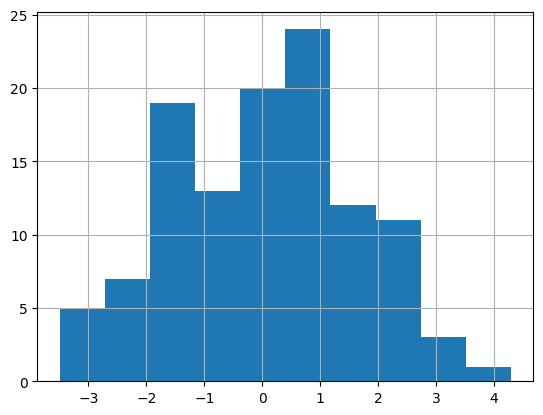

In [27]:
# Now, the URI scores can be visualized through a histogram:
df_Z["URI"].hist()

In [28]:
# This histogram shows the distribution of counties according to the calculated unmet fracture risk.
# The largest concentration of counties sits around the standard deviation values of 0-1.5, while 
# the remaining counties disperse in both the left (lower risk) and right (higher risk) directions. 
# The histogram is slightly bimodal, with a secondary peak occurring around approximately -1 to 
# -2 standard deviations. Overall, the histogram enables visualization
# of county-level fracture risk distribution, with with both lower- and higher-risk groups present.  

In [29]:
# To test symmetry of the histogram and count how many counties have a URI greater than zero, 
# the Pandas sum() function can be utilized:
(df_Z["URI"] > 0).sum()

np.int64(59)

In [30]:
# Approximately 59 out of 115 counties, or a little over 51%, have a positive URI score. This indicates even 
# distribution and an almost-even split, with a very slight tendency toward higher-risk values. In other words, 
# there is variation among the URI scores of the counties, but no extreme polarization.

In [31]:
# Step 6: Now that the risk scores have been calculated, the data can be visualized and interpreted. 
# To begin with, the counties at highest risk are identified. 

In [32]:
# Counties at highest biological risk:
h_bio = df_Z.nlargest(5, "Biological_risk")["cnty_name"].tolist()
# Counties at highest socioeconomic risk:
h_soc = df_Z.nlargest(5, "Socioeconomic_risk")["cnty_name"].tolist()
# Counties at highest healthcare access risk:
h_hea = df_Z.nlargest(5, "Healthcare_access")["cnty_name"].tolist()
# Counties at highest total risk:
h_URI = df_Z.nlargest(5, "URI")["cnty_name"].tolist()
# Counties at lowest total risk:
l_URI = df_Z.nsmallest(5, "URI")["cnty_name"].tolist() 

print("Counties at highest biological risk: " +", ".join(h_bio) +"\n"
     + "Counties at highest socioeconomic risk: "+", ".join(h_soc) +"\n"
     + "Counties at highest healthcare access risk: "+", ".join(h_hea) +"\n"
     + "Counties at highest total risk: " + ", ".join(h_URI) +"\n"
     + "Counties at lowest total risk: " + ", ".join(l_URI)
     )

Counties at highest biological risk: Hickory, Stone, Benton, Camden, Ozark
Counties at highest socioeconomic risk: Pemiscot, St. Louis City, Mississippi, Dunklin, Washington
Counties at highest healthcare access risk: Douglas, Ozark, Carter, Shelby, Scotland
Counties at highest total risk: Hickory, Ozark, Douglas, Wayne, Shannon
Counties at lowest total risk: DeKalb, St. Charles, Platte, Clay, Boone


Text(0.5, 1.0, 'Top 10 Missouri Counties by URI')

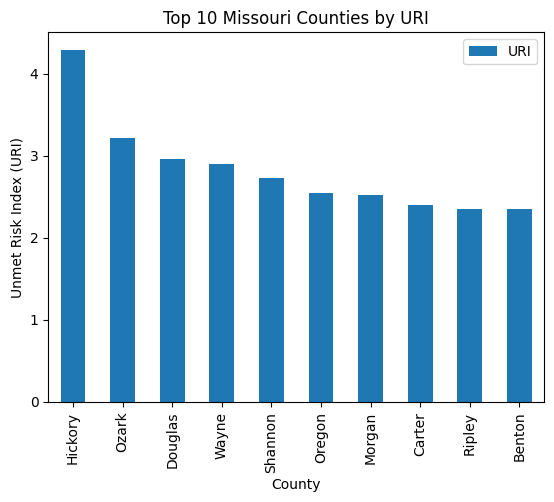

In [33]:
# A visual (bar chart) enables visual comparison of risk.
# The top 10 counties with the highest unmet fracture risk scores are presented in the following bar chart. 
df_bar = df_Z.nlargest(10, "URI")[["cnty_name", "URI"]] # filtering the top 10 counties with highest URI scores 
# and storing them in a new data frame
df_bar = df_bar.set_index("cnty_name") # assigning the index to the county name (so county names are labeled on the x-axis)
bar_plot = df_bar.plot.bar() # plotting the counties 
bar_plot.set_xlabel("County") #  assigning X-axis title
bar_plot.set_ylabel("Unmet Risk Index (URI)") # assigning Y-axis title 
bar_plot.set_title("Top 10 Missouri Counties by URI") # assigning plot title

In [34]:
# Next, a county-level Missouri heatmap is created. 
# Geopandas are used to create the geographic map and MatPlotLib to visualize (plot) the map.
import geopandas as gpd
import matplotlib.pyplot as plt
# A heatmap can help visualize geographical fracture risk distribution across the state of Missouri. 
# A color legend makes the heatmap straightforward and interpretable.
# To create a heatmap, it is necessary to be import the state county map. 
# The US Census Bureau provides Topologically Integrated Geographic Encoding and Referencing maps that can be downloaded
# as a zip file containing the maps for all US states.⁷ 
geo_map =  gpd.read_file("/kaggle/input/datasets/anabjelica/mo-county-map") # loading the zip file into a new data frame
geo_map.columns # checking to see the names of the columns in the GeoJSON (heatmap) data frame


Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOIDFQ', 'GEOID', 'NAME',
       'NAMELSAD', 'STUSPS', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER',
       'geometry'],
      dtype='object')

In [35]:
# To find the unique state ID (STATEP) code of Missouri, all the unique state IDs can be printed:
state_codes = geo_map[["STATEFP", "STATE_NAME"]].drop_duplicates()
print(state_codes)

     STATEFP                                    STATE_NAME
0         01                                       Alabama
4         05                                      Arkansas
7         06                                    California
12        08                                      Colorado
14        10                                      Delaware
15        12                                       Florida
21        02                                        Alaska
23        13                                       Georgia
29        16                                         Idaho
32        17                                      Illinois
35        18                                       Indiana
37        19                                          Iowa
38        04                                       Arizona
40        20                                        Kansas
45        21                                      Kentucky
46        22                                     Louisia

In [36]:
# The data above shows that Missouri is state code #29. The state of Missouri can now be filtered as a geographical
# county-level map. 
geo_map = geo_map[geo_map["STATEFP"] == "29"]
# Checking to make sure the Missouri data loaded correctly:
geo_map.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
70,29,113,00758511,0500000US29113,29113,Lincoln,Lincoln County,MO,Missouri,06,1622789067,36002285,"POLYGON ((-91.26382 39.00761, -91.26311 39.037..."
204,29,041,00758475,0500000US29041,29041,Chariton,Chariton County,MO,Missouri,06,1945541994,40353307,"POLYGON ((-93.28745 39.6833, -93.28613 39.6838..."
205,29,065,00758487,0500000US29065,29065,Dent,Dent County,MO,Missouri,06,1949641179,4518781,"POLYGON ((-91.80837 37.67827, -91.80819 37.702..."
459,29,143,00758526,0500000US29143,29143,New Madrid,New Madrid County,MO,Missouri,06,1747940899,56236293,"POLYGON ((-89.97129 36.39314, -89.97032 36.397..."
460,29,031,00758470,0500000US29031,29031,Cape Girardeau,Cape Girardeau County,MO,Missouri,06,1498351218,20284964,"POLYGON ((-89.8668 37.21898, -89.86326 37.2190..."


In [37]:
# To ensure the heatmap county names match the county names in the risk score data frame, it is important to
# standardize the county names in both data frames to make sure they match exactly. 
# First all the county name values will be set to lowercase:
df_Z["cnty_name"] = df_Z["cnty_name"].str.lower().str.strip()
geo_map["NAME"] = geo_map["NAME"].str.lower().str.strip()
# Now the two data frames can be joined:
geo_map = geo_map.merge(
    df_Z[["cnty_name", "URI"]],
    left_on="NAME",
    right_on="cnty_name"
)
geo_map.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry,cnty_name,URI
0,29,113,00758511,0500000US29113,29113,lincoln,Lincoln County,MO,Missouri,06,1622789067,36002285,"POLYGON ((-91.26382 39.00761, -91.26311 39.037...",lincoln,-1.607129
1,29,041,00758475,0500000US29041,29041,chariton,Chariton County,MO,Missouri,06,1945541994,40353307,"POLYGON ((-93.28745 39.6833, -93.28613 39.6838...",chariton,0.813641
2,29,065,00758487,0500000US29065,29065,dent,Dent County,MO,Missouri,06,1949641179,4518781,"POLYGON ((-91.80837 37.67827, -91.80819 37.702...",dent,1.262590
3,29,143,00758526,0500000US29143,29143,new madrid,New Madrid County,MO,Missouri,06,1747940899,56236293,"POLYGON ((-89.97129 36.39314, -89.97032 36.397...",new madrid,1.789479
4,29,031,00758470,0500000US29031,29031,cape girardeau,Cape Girardeau County,MO,Missouri,06,1498351218,20284964,"POLYGON ((-89.8668 37.21898, -89.86326 37.2190...",cape girardeau,-1.653921


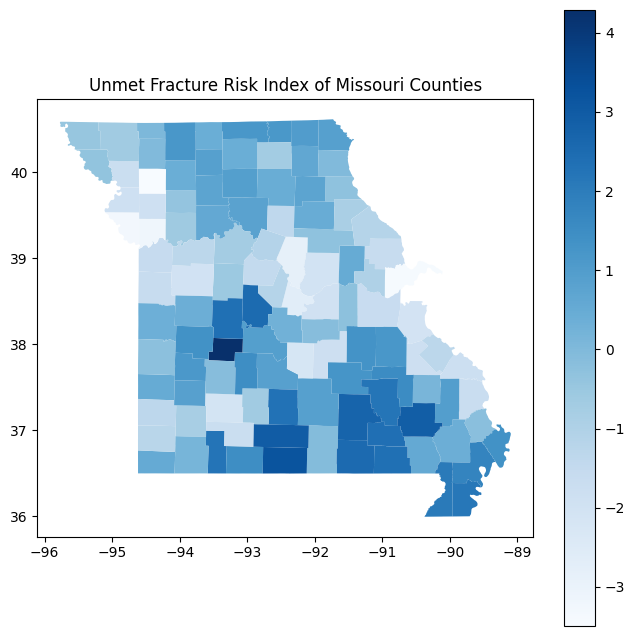

In [38]:
# Finally, the heatmap can be plotted.
# The appropriate package must be imported:
import matplotlib.pyplot as plot
# Plotting the heatmap: 
geo_map.plot(
    column="URI",
    cmap="Blues",
    legend=True,
    figsize=(8,8)
)
plot.title("Unmet Fracture Risk Index of Missouri Counties") # adding a title to the heatmap  
plot.show() # printing the visualization

In [39]:
# The heatmap shows which counties and areas of Missouri are most susceptible to fracture risk. The deeper shade of blue,
# the higher the county URI score. General areas with higher fracture risk appear to be west-central and south-central 
# Missouri. Areas of lower risk appear to be northern and northeastern Missouri. 

In [40]:
# Step 6 (cont'd): K-means clustering can help identify natural grouping of counties based on the three risk
# score factors - biological risk, socioeconomic risk and healthcare access. Here,
# three clusters of Missouri counties are identified: low-risk, moderate-risk, and high-risk counties. 
from sklearn.cluster import KMeans

cluster = df_Z[["Biological_risk", "Socioeconomic_risk", "Healthcare_access"]]

kmeans = KMeans(n_clusters=3, random_state=0)
df_Z["cluster"] = kmeans.fit_predict(cluster)
df_Z.groupby("cluster")[["URI"]].mean()

,URI
cluster,
0,0.470908
1,1.850964
2,-1.655043


In [41]:
# Cluster 0 represents counties at moderate risk. Cluster 1 represents counties at comparatively high risk, and 
# Cluster 2 represents counties at comparatively low risk. The mean of each cluster is given in the right column. 
# Here are the lists of counties that belong to each cluster:
clusters = df_Z.groupby("cluster")["cnty_name"].apply(list)

print("Moderate risk counties: " + ", ".join(df_Z[df_Z["cluster"] == 0]["cnty_name"].tolist()))
print("\n")
print("High risk counties: " + ", ".join(df_Z[df_Z["cluster"] == 1]["cnty_name"].tolist()))
print("\n")
print("Low risk counties: " + ", ".join(df_Z[df_Z["cluster"] == 2]["cnty_name"].tolist()))

Moderate risk counties: atchison, audrain, barry, barton, bates, benton, caldwell, camden, carroll, cedar, chariton, clark, dade, daviess, gasconade, gentry, grundy, harrison, henry, holt, howell, knox, lewis, linn, livingston, macon, madison, maries, marion, mercer, miller, monroe, montgomery, polk, putnam, ralls, st. clair, schuyler, scotland, shelby, stoddard, stone, sullivan, vernon, worth


High risk counties: bollinger, butler, carter, crawford, dallas, dent, douglas, dunklin, hickory, iron, laclede, mcdonald, mississippi, morgan, new madrid, oregon, ozark, pemiscot, reynolds, ripley, shannon, taney, texas, washington, wayne, wright, st. louis city


Low risk counties: adair, andrew, boone, buchanan, callaway, cape girardeau, cass, christian, clay, clinton, cole, cooper, dekalb, franklin, greene, howard, jackson, jasper, jefferson, johnson, lafayette, lawrence, lincoln, moniteau, newton, nodaway, osage, perry, pettis, phelps, pike, platte, pulaski, randolph, ray, st. charles, ste

In [42]:
# The clustering output shows a trend that supports the results of the model output. All of the top ten counties 
# previously identified for high fracture risk, including Douglas, Ozark, and Hickory, are in the "High risk" 
# (Cluster 1) group. Similarly, the counties identified for low risk, including DeKalb, St. Charles, and Platte, are in 
# the "Low risk" (Cluster 2) group.

In [43]:
# Step 7: The Data Story is documented throughout the course of this notebook through comments and explanations,
# and is also communicated through a brief abstract and visuals in the accompanying visual presentation.

In [44]:
# Conclusive Summary of Data Science Life Cycle:
# Step 1: The project goals were outlined and the main question was stated.
# Step 2: The target audience was acknowledged, and the written communication was created with the audience in mind. 
#         The Missouri County Dataset was downloaded, and then uploaded to the notebook.
# Step 3: The data variables were organized and grouped, and the data was cleaned and standardized. 
# Step 4: The data was summarized and visualized using a box plot. Outliers were identified and carefully examined.
# Step 5: The statistical model was built through steps including z-score standardization and variable aggregation.
#         The model was visualized using a histogram and results were explained. 
# Step 6: The model output was visualized geographically by mapping risk scores to Missouri counties.  
#         The results were interpreted and further validated by clustering. 
# Step 7: (See visual presentation)
# Step 8: (See below)

In [45]:
# Step 8: The DSA lifecycle began with a simple question, which led to data-backed answers in the form of 
# geographical visualizations, categorical groupings, and organized clusters. Though the main question ("which Missouri
# counties are most susceptible to fracture risk?") was addressed, it is equally important to reflect on what this means
# on a public health scale. Awareness of fracture risk can help identify areas of need, support the development and 
# implementation of preventive measures to avoid future health crises, and promote early screening and education 
# for at-risk populations. As the global population continues to age, identifying individuals at risk of
# osteoporosis ealier and more accurately will become increasingly important, and access to screening, preventive care, 
# and education will play a role improving patient health outcomes and, eventually, saving lives. 


In [46]:
# Thank you for reading this Data Story!

In [47]:
# References:
# 1. The Facts About Osteoporosis. https://www.health.ny.gov/publications/2047/.
# 2. Coughlan, T. & Dockery, F. Osteoporosis and fracture risk in older people. Clin Med (Lond) 14, 187–191 (2014).
# 3. Park, M., Cha, Y., Kim, J.-H. & Kim, S. H. Regional disparities in the risk of secondary fractures in patients with hip fractures. Injury 55, 111864 (2024).
# 4. Valentin, G. et al. Socio-economic inequalities in fragility fracture incidence: a systematic review and meta-analysis of 61 observational studies. Osteoporos Int 32, 2433–2448 (2021).
# 5. Douglas County Missouri natural disaster risk assessment on Augurisk. Douglas County Missouri natural disaster risk assessment on Augurisk https://www.augurisk.com/risk/state/missouri/douglas-county/29067.
# 6. Scotland County, MO | Data USA. https://datausa.io/profile/geo/scotland-county-mo.
# 7. Index of /geo/tiger. https://www2.census.gov/geo/tiger/.


